In [1]:
# Cell 1
import os, sys, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from scipy.stats import beta as beta_dist

# (khusus Colab, di laptop dilewati otomatis)
if os.path.exists('/content') and not os.path.exists('/content/stat-audit-pandas-sti-2025'):
    os.system('git clone https://github.com/aqilfadria/stat-audit-pandas-sti-2025.git /content/stat-audit-pandas-sti-2025')
    os.chdir('/content/stat-audit-pandas-sti-2025/notebooks')

# cari folder project supaya bisa import src/inference.py
for c in ['.', '..', os.getcwd(), os.path.dirname(os.getcwd())]:
    if os.path.isfile(os.path.join(c, 'src', 'inference.py')):
        sys.path.insert(0, os.path.abspath(c)); break
from src.inference import (ci_proportion_wald, ci_proportion_wilson,ci_poisson_mean, credible_interval_beta)
sns.set_theme(style='whitegrid', palette='muted')

# ambil data
pr = pd.read_csv('../data/clean/pr_dataset.csv')
df = pd.read_csv('../data/clean/dataset.csv')
k = int(pr['merged'].dropna().astype(int).sum())   # PR merged
n = int(pr['merged'].dropna().shape[0])             # total PR
lambda_hat = float(df['comments'].dropna().mean())  # rata2 komentar
n_pois = int(df['comments'].dropna().shape[0])
print(f'OK. k(merged)={k}, n={n}, theta_hat={k/n:.4f}, lambda_hat={lambda_hat:.4f}')

OK. k(merged)=3293, n=5000, theta_hat=0.6586, lambda_hat=2.3841


CI theta (Wald)   : [0.6455, 0.6717]
CI theta (Wilson) : [0.6453, 0.6716]
CI lambda         : [2.3385, 2.4298]
Credible theta    : [0.6453, 0.6716]


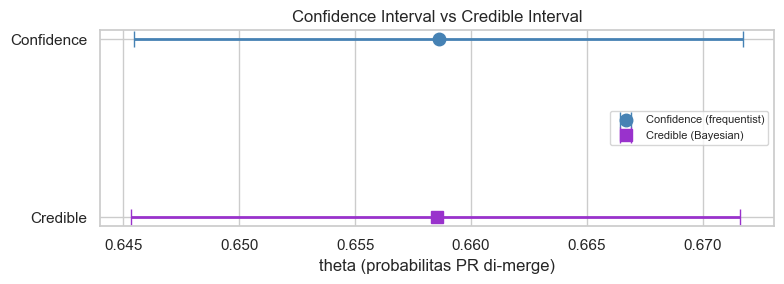

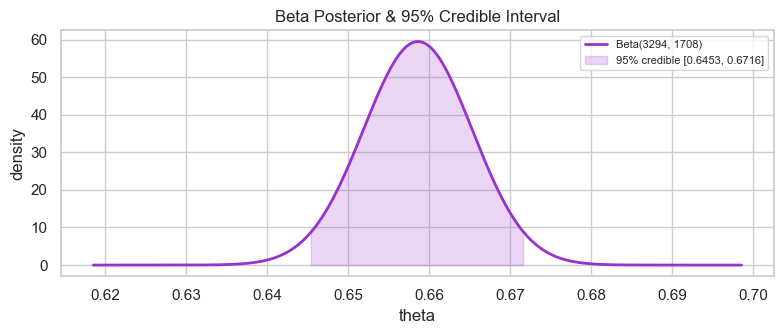

In [2]:
# Cell 2: confidence interval, credible interval, grafik
ci_wald   = ci_proportion_wald(k, n)            # CI frequentist untuk theta
ci_wilson = ci_proportion_wilson(k, n)          # pembanding
ci_lambda = ci_poisson_mean(lambda_hat, n_pois) # CI untuk rata2 komentar
cred      = credible_interval_beta(k+1, (n-k)+1)# credible interval Bayesian

print(f"CI theta (Wald)   : [{ci_wald['lower']:.4f}, {ci_wald['upper']:.4f}]")
print(f"CI theta (Wilson) : [{ci_wilson['lower']:.4f}, {ci_wilson['upper']:.4f}]")
print(f"CI lambda         : [{ci_lambda['lower']:.4f}, {ci_lambda['upper']:.4f}]")
print(f"Credible theta    : [{cred['lower']:.4f}, {cred['upper']:.4f}]")

# Grafik 1: CI vs Credible untuk theta
fig, ax = plt.subplots(figsize=(8, 3))
ax.errorbar(ci_wald['theta_hat'], 1, xerr=ci_wald['margin'], fmt='o',
            color='steelblue', capsize=6, lw=2, ms=9, label='Confidence (frequentist)')
ax.errorbar(cred['mean'], 0,
            xerr=[[cred['mean']-cred['lower']], [cred['upper']-cred['mean']]],
            fmt='s', color='darkorchid', capsize=6, lw=2, ms=9, label='Credible (Bayesian)')
ax.set_yticks([0,1]); ax.set_yticklabels(['Credible','Confidence'])
ax.set_xlabel('theta (probabilitas PR di-merge)')
ax.set_title('Confidence Interval vs Credible Interval')
ax.legend(fontsize=8); plt.tight_layout()
plt.savefig('../report/fig_ci_vs_credible.png', dpi=150, bbox_inches='tight'); plt.show()

# Grafik 2: posterior Beta + credible interval
xs = np.linspace(cred['mean']-0.04, cred['mean']+0.04, 600)
pdf = beta_dist.pdf(xs, k+1, (n-k)+1)
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(xs, pdf, color='darkorchid', lw=2, label=f'Beta({k+1}, {(n-k)+1})')
mask = (xs>=cred['lower']) & (xs<=cred['upper'])
ax.fill_between(xs[mask], pdf[mask], color='darkorchid', alpha=0.2,
                label=f"95% credible [{cred['lower']:.4f}, {cred['upper']:.4f}]")
ax.set_xlabel('theta'); ax.set_ylabel('density')
ax.set_title('Beta Posterior & 95% Credible Interval')
ax.legend(fontsize=8); plt.tight_layout()
plt.savefig('../report/fig_credible_interval.png', dpi=150, bbox_inches='tight'); plt.show()

In [3]:
# Cell 3: simpan hasil
hasil = {
    'theta_ci_wald':   {'lower': ci_wald['lower'],   'upper': ci_wald['upper']},
    'theta_ci_wilson': {'lower': ci_wilson['lower'], 'upper': ci_wilson['upper']},
    'lambda_ci':       {'lower': ci_lambda['lower'], 'upper': ci_lambda['upper']},
    'theta_credible':  {'lower': cred['lower'],      'upper': cred['upper']},
}
os.makedirs('../data/clean', exist_ok=True)
with open('../data/clean/inference_results.json', 'w') as f:
    json.dump(hasil, f, indent=2)
print('Tersimpan:'); print(json.dumps(hasil, indent=2))

Tersimpan:
{
  "theta_ci_wald": {
    "lower": 0.645457,
    "upper": 0.671743
  },
  "theta_ci_wilson": {
    "lower": 0.645339,
    "upper": 0.671617
  },
  "lambda_ci": {
    "lower": 2.338462,
    "upper": 2.429823
  },
  "theta_credible": {
    "lower": 0.645337,
    "upper": 0.671616
  }
}
